In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)

# Imports

In [2]:
file_path = '../data/raw_sweeps' # add path to data 

In [3]:
from sweep import sweep_load as sl
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline


import sys
sys.path.append("../utils")

In [4]:
scale = 0.56
plt.rcParams.update({
    # Font and font sizes
    'font.family': 'sans-serif',
    'axes.labelsize': 8, 
    'axes.titlesize': 8,
    'font.size': 9,
    'legend.title_fontsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,

    # Ticks
    'xtick.direction': 'in',
    'xtick.top': 'True',
    'ytick.direction': 'in',
    'ytick.right': 'True',

    'xtick.major.size': 5*scale,
    'xtick.major.width': 1.5*scale,
    'xtick.minor.size': 2.5*scale,
    'xtick.minor.width': 1.5*scale,

    'ytick.major.size': 5*scale,
    'ytick.major.width': 1.5*scale,
    'ytick.minor.size': 2.5*scale,
    'ytick.minor.width': 1.5*scale,


    # Linewidths
    'axes.linewidth': 1.5*scale,
    'lines.linewidth': 2.5*scale,
})

# Tc data

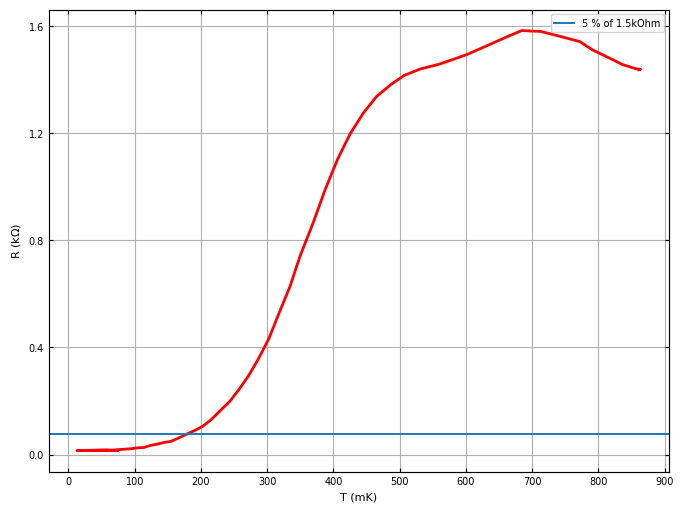

In [7]:
def plot_RT_onept(fig, ax, color="r"):  
    # 300ms time constant
    files= [2026]
    
    contact_pairs = {
        'long': {'indices': [1], 'norm': colors.SymLogNorm(linthresh=10, vmin=-3E4, vmax=3E4), 'cmap': 'RdBu_r', 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    for pair, options in contact_pairs.items():   
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            for i, file in enumerate(files):
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                idc_vec = data['xs']
                phase = data[f'sr830_{ind}_P']
                temp_vec = data['T_probe']
    
                I = data['sr830_4_X']
                Vxx = data[f'sr830_{ind}_X']
                zs = Vxx/I
                
                ax.plot(temp_vec[::10]*1e3, zs[::10]/1e3, color=color, lw=2.0)    
            ax.set_ylabel("R (k$\Omega$)")
            ax.set_xlabel('T (mK)')
            ax.xaxis.set_major_locator(plt.MaxNLocator(10))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.axhline(0.05*1.5, label="5 % of 1.5kOhm")
            ax.grid()
            ax.legend()

    return temp_vec, zs
    

fig = plt.figure(figsize=(8,6))
ax = plt.gca()
temp_vec, res_vec = plot_RT_onept(fig, ax)

In [8]:
def hn(T, R0, b, T_BKT):
    return R0*np.exp(-b/np.power((T - T_BKT), 0.5))

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_49303/1812511931.py:2: RuntimeWarning: invalid value encountered in power
  return R0*np.exp(-b/np.power((T - T_BKT), 0.5))


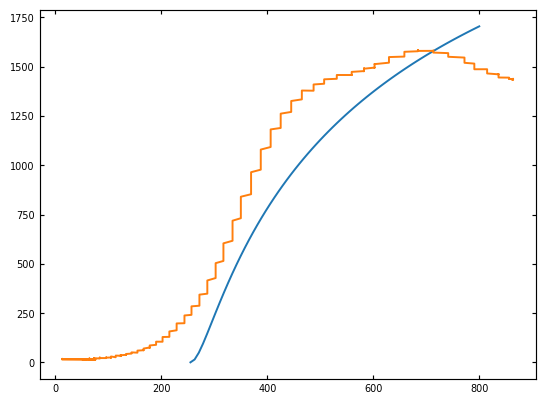

In [27]:
T_vec = np.linspace(10, 800, 101)
R0 = 4000
b = 20
T_BKT = 250
hn_vec = hn(T_vec, R0, b, T_BKT)

plt.plot(T_vec, hn_vec)
plt.plot(temp_vec*1e3, res_vec)

R0    = 4288.10 ± 171.59
b     = 19.6923 ± 0.7799
T_BKT = 208.28 ± 3.52


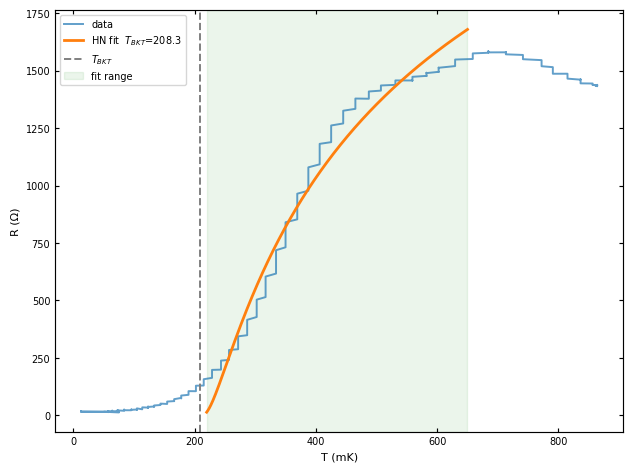

In [55]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def hn(T, R0, b, T_BKT):
    return R0 * np.exp(-b / np.power(np.abs(T - T_BKT), 0.5))


# --- fit range: adjust these two values ---
T_min_fit = 220   # lower bound of fit range (same units as temp_vec*1e3)
T_max_fit = 650   # upper bound of fit range

mask = (temp_vec * 1e3 > T_min_fit) & (temp_vec * 1e3 < T_max_fit)
T_fit = temp_vec[mask] * 1e3
R_fit = res_vec[mask]

p0 = [np.max(res_vec), 20, 150] # initial guess
bounds = (
    [0,   0,   0        ],
    [1e6, 200, T_min_fit]
)

popt, pcov = curve_fit(hn, T_fit, R_fit, p0=p0, bounds=bounds, maxfev=10000)
perr = np.sqrt(np.diag(pcov))

R0_fit, b_fit, T_BKT_fit = popt
R0_err, b_err, T_BKT_err = perr

print(f"R0    = {R0_fit:.2f} ± {R0_err:.2f}")
print(f"b     = {b_fit:.4f} ± {b_err:.4f}")
print(f"T_BKT = {T_BKT_fit:.2f} ± {T_BKT_err:.2f}")

# --- plot ---
T_plot = np.linspace(T_min_fit, T_max_fit, 500)
fig, ax = plt.subplots()
ax.plot(temp_vec * 1e3, res_vec, label="data", alpha=0.7)
ax.plot(T_plot, hn(T_plot, *popt), label=f"HN fit  $T_{{BKT}}$={T_BKT_fit:.1f}", lw=2)
ax.axvline(T_BKT_fit, color="gray", ls="--", label="$T_{BKT}$")
ax.axvspan(T_min_fit, T_max_fit, alpha=0.08, color="green", label="fit range")
ax.set_xlabel("T (mK)")
ax.set_ylabel("R (Ω)")
ax.legend()
plt.tight_layout()
plt.show()